# 3W Dataset: Synthetic Data Generation

Stage 2 showed that the simulated (OLGA) data fails to transfer to the real domain (the F1 drops from 0.98 to 0.07), while expert hand-drawn data transfers moderately well. The real bottleneck, however, is scarcity: the rare events (classes 1, 5, 6, 7, 8) have only 3 to 12 real instances each. In this notebook we put the same generative machinery to two uses:

1. **CVAE rare-event augmentation (Experiment A).** 
   A Conditional VAE trained on the real data generates synthetic rare-event instances; we measure, step by step, whether the generated data reduces the distance to the real domain and improves the downstream Random Forest classifier.
2. **VAE anomaly detection (Experiment B).** 
   A VAE trained **only on Normal instances** (class 0) learns the normal operating envelope; any instance whose reconstruction error is far from the training distribution is an anomaly, that is, one of the 8 undesirable events.

Both experiments work in the same 56-dimensional feature space and on the same fixed train/test split, so their numbers are directly comparable.


## 1. Data Preparation

We work with the **real instances** of the 3W dataset, summarized into
56-dimensional statistical feature vectors (7 statistics x 8 variables) with
the stage-2 pipeline. The instances are split once, at the instance level,
into a fixed stratified 70/30 train/test partition (seed 42): the **same
partition used in stage 2**, so every number in this notebook is directly
comparable with the transfer-learning experiments. The preprocessing that
feeds the classifier experiments (imputation medians, CVAE and VAE
standardization) is fit on the training split only. The distance evaluations
of Sections 3 and 4 standardize each pair jointly (scaler fitted on both
sides, near-zero variances floored at 1e-3) and use all real instances of the
class as the real reference: they are descriptive generator characterization
and feed nothing back into the classifier experiments. Only class 0 is used
for training the VAE of Section 5; all 9 classes are used for testing.


In [1]:
import os, glob, warnings, random
import numpy as np
import pandas as pd
import scipy.linalg
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wasserstein_distance
from scipy.spatial.distance import pdist
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(42)


In [2]:
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

EXTRACTED_DATA_DIR = os.path.join(
    PROJECT_ROOT, 'data',
    'Data for A Realistic and Public Dataset with Rare Undesirable Real Events in Oil Wells',
    'data'
)

CLASS_NAMES = {
    0: 'Normal',
    1: 'Abrupt Increase of BSW',
    2: 'Spurious Closure of DHSV',
    3: 'Severe Slugging',
    4: 'Flow Instability',
    5: 'Rapid Productivity Loss',
    6: 'Quick Restriction in PCK',
    7: 'Scaling in PCK',
    8: 'Hydrate in Production Line',
}
VARIABLE_NAMES = ['P-PDG', 'P-TPT', 'T-TPT', 'P-MON-CKP',
                  'T-JUS-CKP', 'P-JUS-CKGL', 'T-JUS-CKGL', 'QGL']
SOURCES = ['real', 'simulated', 'handdrawn']


In [3]:
def detect_source(filename: str) -> str:
    """
    Detect the source of the instance based on its filename.

    Args:
        filename: the name of the CSV file (e.g., 'DRAWN_1.csv', 'SIMULATED_2.csv', 'WELL_3.csv')
    Returns:
        source: 'handdrawn', 'simulated', 'real', or 'unknown'
    """
    name = os.path.splitext(filename)[0]
    if name.startswith('DRAWN'):   return 'handdrawn'
    if name.startswith('SIMULATED'): return 'simulated'
    if name.startswith('WELL'):    return 'real'
    return 'unknown'

def load_all_instances(data_dir: str, class_names: list) -> dict:
    """
    Load all instances from the extracted data directory, organized by class and source.

    Args:
        data_dir: path to the extracted data directory
        class_names: list of class codes to include
    Returns:
        all_instances: dict of instances per class and source, where each instance is a dict with
            'id': instance identifier (filename without extension),
            'path': path to the CSV file,
            'data': pandas DataFrame with the instance data,
            'n_vars': number of variables (excluding timestamp and class),
            'n_obs': number of observations (rows) in the DataFrame
    """
    all_instances = {}
    for class_code in class_names:
        class_dir = os.path.join(data_dir, str(class_code))
        if not os.path.isdir(class_dir):
            continue
        csv_files = sorted(glob.glob(os.path.join(class_dir, '*.csv')))
        if not csv_files:
            continue
        class_instances = {}
        for fpath in csv_files:
            fname = os.path.basename(fpath)
            source = detect_source(fname)
            df = pd.read_csv(fpath)
            if 'timestamp' in df.columns:
                df['timestamp'] = pd.to_datetime(df['timestamp'])
            instance_id = os.path.splitext(fname)[0]
            if source not in class_instances:
                class_instances[source] = []
            class_instances[source].append({
                'id': instance_id, 'path': fpath, 'data': df,
                'n_vars': len([c for c in df.columns if c not in ('timestamp', 'class')]),
                'n_obs': df.shape[0],
            })
        if class_instances:
            all_instances[class_code] = class_instances
    return all_instances

data = load_all_instances(EXTRACTED_DATA_DIR, CLASS_NAMES)

total = sum(sum(len(lst) for lst in src_dict.values()) for src_dict in data.values())
print(f'Loaded {total} instances across {len(data)} classes.')


Loaded 1984 instances across 9 classes.


In [4]:
# same pipeline as in stage 2
def extract_features(data: dict, source: str, classes: list) -> tuple:
    """
    Extract statistical features per instance.
    7 statistics (mean, std, min, p25, p50, p75, max) x 8 variables = 56 features
    NaN -> column median (or 0 if whole column is NaN), inf -> clipped

    Args:
        data: dict of instances per class and source
        source: 'real', 'simulated', or 'handdrawn'
        classes: list of class codes to include
    Returns:
        (X, y, instance_ids): X is (n_instances, n_features), y the class labels, instance_ids the list of instance identifiers
    """
    features = []
    labels = []
    instance_ids = []

    for cls in classes:
        if cls not in data or source not in data[cls]:
            continue
        for inst in data[cls][source]:
            df = inst['data']
            feats = []
            for var in VARIABLE_NAMES:
                if var in df.columns:
                    vals = df[var].values
                    feats.extend([
                        np.nanmean(vals),
                        np.nanstd(vals),
                        np.nanmin(vals),
                        np.nanpercentile(vals, 25),
                        np.nanpercentile(vals, 50),
                        np.nanpercentile(vals, 75),
                        np.nanmax(vals),
                    ])
                else:
                    feats.extend([np.nan] * 7)

            features.append(feats)
            labels.append(cls)
            instance_ids.append(inst['id'])

    X = np.array(features, dtype=np.float64)
    y = np.array(labels)

    # nan values are replaced with column medians (or 0 if entire column is NaN)
    col_medians = np.nanmedian(X, axis=0)
    nan_mask = np.isnan(X)
    for j in range(X.shape[1]):
        if np.isnan(col_medians[j]):
            col_medians[j] = 0.0
        X[nan_mask[:, j], j] = col_medians[j]

    # replace inf values with column max/min (or 1/-1 if entire column is inf)
    for j in range(X.shape[1]):
        col = X[:, j]
        finite_vals = col[np.isfinite(col)]
        if len(finite_vals) > 0:
            col_max = np.max(finite_vals)
            col_min = np.min(finite_vals)
        else:
            col_max, col_min = 1.0, -1.0
        col[~np.isfinite(col) & (col > 0)] = col_max
        col[~np.isfinite(col) & (col < 0)] = col_min
        # clipping to avoid extreme values
        X[:, j] = np.clip(col, -1e15, 1e15)

    return X, y, instance_ids

stat_names = ['mean', 'std', 'min', 'p25', 'p50', 'p75', 'max']
feature_names = [f'{var}_{stat}' for var in VARIABLE_NAMES for stat in stat_names]

X_real, y_real, ids_real = extract_features(data, 'real', sorted(CLASS_NAMES))
print(f'Real feature matrix: {X_real.shape} ({len(feature_names)} feature dimensions)')
counts = pd.Series(y_real).value_counts().sort_index()
pd.DataFrame({'class': counts.index, 'n_real': counts.values, 'event': [CLASS_NAMES[c][:28] for c in counts.index]})


Real feature matrix: (1025, 56) (56 feature dimensions)


,class,n_real,event
0,0,597,Normal
1,1,5,Abrupt Increase of BSW
2,2,22,Spurious Closure of DHSV
3,3,32,Severe Slugging
4,4,344,Flow Instability
5,5,12,Rapid Productivity Loss
6,6,6,Quick Restriction in PCK
7,7,4,Scaling in PCK
8,8,3,Hydrate in Production Line


In [5]:
RARE_CLASSES = [1, 5, 6, 7, 8]

real_by_class = {c: list(data[c]['real']) for c in sorted(CLASS_NAMES) if 'real' in data.get(c, {})}
all_insts, y_all = [], []
for c in sorted(real_by_class):
    all_insts.extend(real_by_class[c])
    y_all.extend([c] * len(real_by_class[c]))

tr_idx, te_idx, _, _ = train_test_split(np.arange(len(all_insts)), y_all, test_size=0.3, stratify=y_all, random_state=42)

def build_dict(idx: list) -> dict:
    """
    Build a dictionary of instances grouped by class.

    Args:
        idx: list of instance indices

    Returns:
        d: dictionary with class codes as keys and lists of instances as values
    """
    d = {}
    for i in idx:
        inst, c = all_insts[i], y_all[i]
        d.setdefault(c, {'real': []})['real'].append(inst)
    return d

data_train = build_dict(tr_idx)
data_test = build_dict(te_idx)
print(f'Real instances: train {len(tr_idx)}, test {len(te_idx)} (total {len(all_insts)})')


Real instances: train 717, test 308 (total 1025)


In [6]:
X_train, y_train, ids_train = extract_features(data_train, 'real', sorted(CLASS_NAMES))
X_test, y_test, ids_test = extract_features(data_test, 'real', sorted(CLASS_NAMES))
print(f'Train features: {X_train.shape}, test features: {X_test.shape}')

def class_counts(y: np.ndarray) -> pd.Series:
    """
    Count the occurrences of each class in the label array.

    Args:
        y: array of class labels
    Returns:
        pd.Series with counts of each class, indexed by class code
    """
    return pd.Series(y).value_counts().sort_index()

tbl = pd.DataFrame({'train': class_counts(y_train), 'test': class_counts(y_test)})
tbl['event'] = [CLASS_NAMES[c][:28] for c in tbl.index]
tbl

Train features: (717, 56), test features: (308, 56)


,train,test,event
0,418,179,Normal
1,4,1,Abrupt Increase of BSW
2,15,7,Spurious Closure of DHSV
3,22,10,Severe Slugging
4,241,103,Flow Instability
5,8,4,Rapid Productivity Loss
6,4,2,Quick Restriction in PCK
7,3,1,Scaling in PCK
8,2,1,Hydrate in Production Line


In [7]:
def run_rf_evaluation(X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, y_te: np.ndarray, classes: list, n_seeds: int = 10, class_weight: dict = None) -> dict:
    """
    Run Random Forest evaluation over multiple seeds and compute macro and per-class F1 scores.

    Args:
        X_tr: training feature matrix
        y_tr: training labels
        X_te: test feature matrix
        y_te: test labels
        classes: list of class codes to evaluate
        n_seeds: number of random seeds for evaluation
        class_weight: optional dictionary mapping class codes to weights for handling class imbalance
    Returns:
        dict with 'macro' F1 scores and 'per_class' F1 scores for each class across seeds
    """
    macro, per_class = [], {c: [] for c in classes}
    for k in range(n_seeds):
        rf = RandomForestClassifier(n_estimators=100, random_state=42 + k,
                                    n_jobs=-1, class_weight=class_weight)
        rf.fit(X_tr, y_tr)
        y_pred = rf.predict(X_te)
        macro.append(f1_score(y_te, y_pred, average='macro'))
        for c in classes:
            per_class[c].append(f1_score(y_te == c, y_pred == c))
    return {'macro': np.array(macro), 'per_class': {c: np.array(v) for c, v in per_class.items()}}

def rare_agg_per_seed(res):
    """
    Aggregate F1 scores for rare classes across seeds.
    Args:
        res: dictionary with 'per_class' F1 scores for each class across seeds
    Returns:
        mean_ra: mean rare-aggregate F1 score across seeds
        std_ra: standard deviation of rare-aggregate F1 score across seeds
    """
    vals = np.mean([res['per_class'][c] for c in RARE_CLASSES], axis=0)
    return float(np.mean(vals)), float(np.std(vals))

all_classes = sorted(CLASS_NAMES)
baseline_results = run_rf_evaluation(X_train, y_train, X_test, y_test, all_classes)
base_ra, base_rs = rare_agg_per_seed(baseline_results)
print(f'No-augmentation baseline: rare-agg F1 = {base_ra:.3f} | macro F1 = {baseline_results["macro"].mean():.3f}')


No-augmentation baseline: rare-agg F1 = 0.571 | macro F1 = 0.741


## 2. Conditional VAE (CVAE)

A standard VAE trained on all classes can only reproduce the training
distribution, with no mechanism to generate a specific rare event on demand.
The **Conditional VAE** solves this by feeding the class as a one-hot
condition to both the encoder and the decoder, giving us explicit control over
*which* class we generate. All 9 classes share a single network, so the rare
classes (2 to 8 training instances) borrow statistical structure from the
common ones.

**Architecture:**
- **Encoder**: Input (56 features + 9 class labels) → 64 → 64 → μ, σ (latent dim = 8)
- **Decoder**: Latent (8 + 9 class labels) → 64 → 64 → 56 reconstructed features
- **Loss**: Reconstruction (MSE) + KL Divergence

**Training:** inverse-frequency batch sampling (the rare classes would
otherwise appear in a minority of batches and receive almost no gradient),
Adam with a Cosine Annealing learning rate scheduler over 200 epochs.


In [8]:
class CVAE(nn.Module):
    """
    Class-conditioned VAE. Condition (one-hot) is concatenated to the input
    of the encoder and to the latent code of the decoder.
    """
    def __init__(self, input_dim: int, n_classes: int, latent_dim: int = 8, hidden: int = 64):
        super().__init__()
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + n_classes, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )

    def encode(self, x: torch.Tensor, c: torch.Tensor):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor, c: torch.Tensor):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z, c)
        return x_rec, mu, logvar


def elbo_loss(x: torch.Tensor, x_rec: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor, beta: float = 1.0) -> tuple:
    """
    Compute the ELBO loss for the CVAE.

    Args:
        x: original input tensor
        x_rec: reconstructed input tensor from the decoder
        mu: mean of the latent distribution
        logvar: log variance of the latent distribution
        beta: weight for the KL divergence term (default is 1.0)
    Returns:
        total_loss: total ELBO loss (reconstruction + beta * KL divergence)
        recon: reconstruction loss (MSE)
        kl: KL divergence loss
    """
    recon = F.mse_loss(x_rec, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu ** 2 - torch.exp(logvar))
    return recon + beta * kl, recon, kl


In [9]:
"""
Preprocessing steps:
1. Compute the mean and standard deviation of the training features (X_train).
2. Identify degenerate (constant) columns where the standard deviation is below a threshold (1e-12).
3. Replace the standard deviation of degenerate columns with 1.0 to avoid division by zero during standardization.
4. Standardize the training features by subtracting the mean and dividing by the standard deviation.
5. Create one-hot encoded labels for the training data.
"""
feat_mu = np.mean(X_train, axis=0)
feat_sd = np.std(X_train, axis=0)
degenerate = feat_sd < 1e-12
feat_sd[degenerate] = 1.0
X_train_std = (X_train - feat_mu) / feat_sd

# print(f'Degenerate (constant) columns: {degenerate.sum()} of {X_train.shape[1]}')
# print('\tP-PDG/QGL constant-0 and T-JUS-CKGL missing-in-class-0 stats are flat.')

# One-hot class condition encoding (9 classes)
Y_train_oh = np.zeros((len(y_train), 9))
Y_train_oh[np.arange(len(y_train)), y_train] = 1.0

assert not np.isnan(X_train_std).any() and np.isfinite(X_train_std).all()
X_train_std = X_train_std.astype(np.float32)

# Inverse-frequency batch sampling, so that every batch has expected uniform class composition
class_counts_y = np.bincount(y_train)
class_weights = 1.0 / class_counts_y[y_train].astype(np.float64)
sampler = WeightedRandomSampler(class_weights, num_samples=len(y_train), replacement=True)
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_std), torch.tensor(Y_train_oh, dtype=torch.float32)),
    batch_size=64, sampler=sampler)

LATENT_DIM, HIDDEN, BETA, LR, EPOCHS = 8, 64, 1.0, 1e-3, 200
print('Hyperparameters:', dict(LATENT_DIM=LATENT_DIM, HIDDEN=HIDDEN, BETA=BETA, LR=LR, EPOCHS=EPOCHS, BATCH=64))
print('\nPer-class training counts:')
class_counts(y_train)


Hyperparameters: {'LATENT_DIM': 8, 'HIDDEN': 64, 'BETA': 1.0, 'LR': 0.001, 'EPOCHS': 200, 'BATCH': 64}

Per-class training counts:


0    418
1      4
2     15
3     22
4    241
5      8
6      4
7      3
8      2
Name: count, dtype: int64

epoch  50 | ELBO 0.8201 | recon 0.4432 | KL 0.3768
epoch 100 | ELBO 0.6284 | recon 0.3513 | KL 0.2770
epoch 150 | ELBO 0.6063 | recon 0.3319 | KL 0.2743
epoch 200 | ELBO 0.5582 | recon 0.3172 | KL 0.2410

Final mean KL: 0.2410 nats/sample


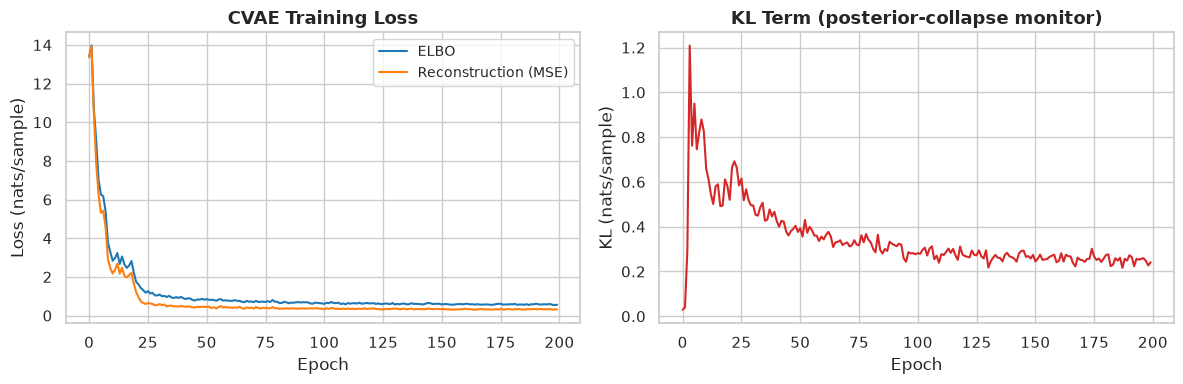

In [10]:
set_seed(42)
model = CVAE(input_dim=X_train_std.shape[1], n_classes=9,
             latent_dim=LATENT_DIM, hidden=HIDDEN)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

history = {'elbo': [], 'recon': [], 'kl': []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    e_elbo = e_recon = e_kl = 0.0
    n_batches = 0
    for xb, cb in train_loader:
        optimizer.zero_grad()
        x_rec, mu, logvar = model(xb, cb)
        loss, recon, kl = elbo_loss(xb, x_rec, mu, logvar, beta=BETA)
        loss.backward()
        optimizer.step()
        e_elbo += loss.item(); e_recon += recon.item(); e_kl += kl.item()
        n_batches += 1
    scheduler.step()
    history['elbo'].append(e_elbo / n_batches)
    history['recon'].append(e_recon / n_batches)
    history['kl'].append(e_kl / n_batches)
    if epoch % 50 == 0:
        print(f'epoch {epoch:3d} | ELBO {history["elbo"][-1]:.4f} | recon {history["recon"][-1]:.4f} | KL {history["kl"][-1]:.4f}')

print(f'\nFinal mean KL: {history["kl"][-1]:.4f} nats/sample')

# NOTE: pay attention to a very low KL value (<0.05 nats/sample) as it indicates posterior collapse, 
# which is a common issue in VAEs where the latent space fails to capture meaningful information.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['elbo'], label='ELBO', color='#1f77b4', linewidth=1.5)
axes[0].plot(history['recon'], label='Reconstruction (MSE)', color='#ff7f0e', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (nats/sample)')
axes[0].set_title('CVAE Training Loss', fontweight='bold', fontsize=13); axes[0].legend(fontsize=10)
axes[1].plot(history['kl'], color='#d62728', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('KL (nats/sample)')
axes[1].set_title('KL Term (posterior-collapse monitor)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 2.1 Analyzing the Learned Representations

Before trusting the CVAE as a generator, we inspect its latent space. Because
the class label is explicitly fed to the decoder, the encoder is not forced to
store the class identity in the latent code. If the conditioning works, the
class structure should partially *collapse* in the latent space: the 9 classes
become less separable there than in the raw feature space, and the remaining
latent variance describes the within-class physics. We verify this by encoding
the real training instances and comparing the mean pairwise class-centroid
distance in feature space versus latent space, together with a t-SNE of the
latent codes.


Mean pairwise class-centroid distance | feature space: 22.441 | latent space: 0.883
Conditioning collapsed class separability by 96.1%


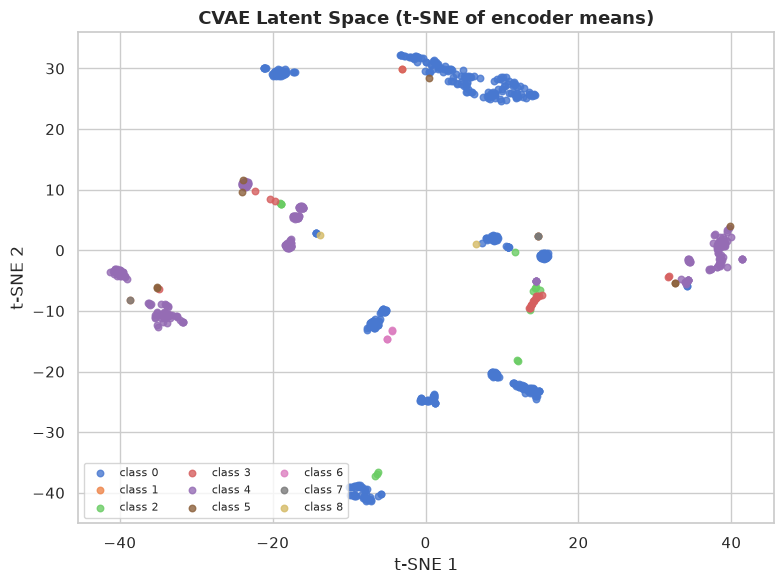

In [11]:
model.eval()
with torch.no_grad():
    mu_z, _ = model.encode(torch.tensor(X_train_std), torch.tensor(Y_train_oh, dtype=torch.float32))
z_train = mu_z.numpy()

def mean_pairwise_centroid_distance(X: np.ndarray, y: np.ndarray) -> float:
    """
    Compute the mean pairwise distance between class centroids.
    Args:
        X: feature matrix (n_samples, n_features)
        y: class labels (n_samples,)
    Returns:
        mean_distance: mean pairwise distance between class centroids
    """
    cents = np.array([X[y == c].mean(axis=0) for c in sorted(np.unique(y))])
    return float(pdist(cents).mean())

feat_cent = mean_pairwise_centroid_distance(X_train_std, y_train)
lat_cent = mean_pairwise_centroid_distance(z_train, y_train)
print(f'Mean pairwise class-centroid distance | feature space: {feat_cent:.3f} | latent space: {lat_cent:.3f}')
print(f'Conditioning collapsed class separability by {100 * (1 - lat_cent / feat_cent):.1f}%')

fig, ax = plt.subplots(figsize=(8, 6))
tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(z_train)
for c in sorted(np.unique(y_train)):
    m = y_train == c
    ax.scatter(tsne[m, 0], tsne[m, 1], s=22, alpha=0.8, label=f'class {c}')
ax.set_title('CVAE Latent Space (t-SNE of encoder means)', fontweight='bold', fontsize=13)
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
ax.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


### 2.2 Generating Synthetic Instances

<!--Sampling: z drawn from the standard normal prior, decoded with the one-hot
condition of the class, then inverse-transformed with the training statistics.
Each class uses its own fixed latent seed (42 + class), so generation is
reproducible and the augmentation sweep of Section 4 is nested (N=25 contains
the first 25 draws of N=100).-->

Sampling occurs by drawing z from the standard normal prior, decoding it with the one-hot condition of the class, and then inverse-transforming with the training statistics. Each class uses its own fixed latent seed (42 + class), so generation is reproducible and the augmentation sweep of Section 4 will be nested (N=25 contains the first 25 draws of N=100). The generated instances are then evaluated in two ways:
1. **Distance to the real domain**: the mean pairwise distance between the generated instances and the real instances of the same class, standardized jointly (scaler fitted on both sides, near-zero variances floored at 1e-3). This is a descriptive generator characterization and feeds nothing back into the classifier experiments.
2. **Downstream RF classification**: the generated instances are added to the training set, and a Random Forest is trained on the augmented set and evaluated on the fixed test split. The F1 score is reported for each class and overall macro-averaged. This is the ultimate measure of whether the generated instances are useful for improving the classifier's performance on the rare events.


class | generated mean dev (std units) | frac dims | gen/real std ratio
 class  max_dev  frac_ok  std_ratio
     1    3.044    0.446      0.727
     5    0.940    0.554      1.109
     6    0.817    0.446      1.999
     7    4.482    0.500      0.640
     8   13.465    0.268      0.714


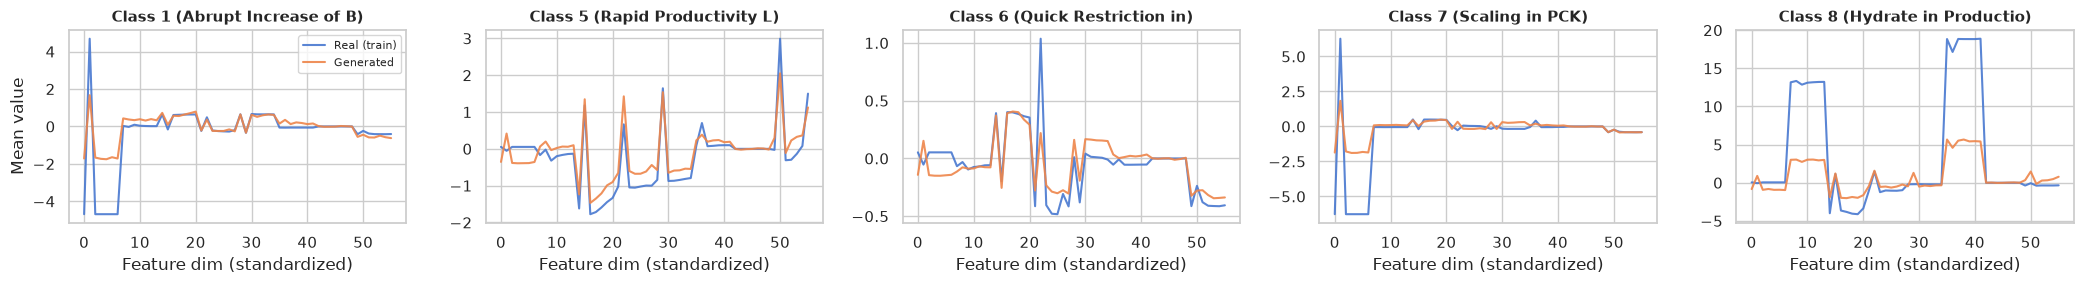

In [13]:
def generate_samples(model: torch.nn.Module, c: int, n: int, feat_mu: np.ndarray, feat_sd: np.ndarray, latent_dim: int = LATENT_DIM, seed: int = 42) -> np.ndarray:
    """
    Generate n feature vectors for class c in the original (unstandardized) space.
    Args:
        model: trained CVAE model
        c: class code (0-8)
        n: number of samples to generate
        feat_mu: mean of training features (for unstandardization)
        feat_sd: standard deviation of training features (for unstandardization)
        latent_dim: dimension of the latent space
        seed: random seed for reproducibility
    Returns:
        x_std: generated samples in the original feature space (n_samples, n_features)
    """
    g = torch.Generator().manual_seed(seed)
    model.eval()
    with torch.no_grad():
        c_oh = torch.zeros(1, model.n_classes)
        c_oh[0, c] = 1.0
        z = torch.randn(n, latent_dim, generator=g)
        x_std = model.decode(z, c_oh.repeat(n, 1))
    return (x_std.numpy() * feat_sd) + feat_mu

# All comparisons in the train-standardized space (feat_mu, feat_sd).
N_SANITY = 50
sanity = {}

print('class | generated mean dev (std units) | frac dims | gen/real std ratio')
# use a df for better formatting
print_rows = []

for c in RARE_CLASSES:
    xg_raw = generate_samples(model, c, N_SANITY, feat_mu, feat_sd, seed=42 + c)
    assert not np.isnan(xg_raw).any() and np.isfinite(xg_raw).all(), f'NaN/inf in generated class {c}'
    xg = (xg_raw - feat_mu) / feat_sd
    xr = (X_train[y_train == c] - feat_mu) / feat_sd
    dev = np.abs(xg.mean(axis=0) - xr.mean(axis=0))
    frac_ok = float(np.mean(dev < 3.0 * np.maximum(xr.std(axis=0), 1e-6)))
    std_ratio = float(xg.std(axis=0).mean() / (xr.std(axis=0).mean() + 1e-12))
    print_rows.append({'class': c, 'max_dev': dev.max(), 'frac_ok': frac_ok, 'std_ratio': std_ratio})
    sanity[c] = xg

print_df = pd.DataFrame(print_rows)
print(print_df.to_string(index=False, float_format='{:.3f}'.format))

# Visualize the mean feature values for real vs generated samples for each rare class
fig, axes = plt.subplots(1, len(RARE_CLASSES), figsize=(4.2 * len(RARE_CLASSES), 3))
for ax, c in zip(axes, RARE_CLASSES):
    ax.plot((X_train[y_train == c] - feat_mu).mean(axis=0) / feat_sd, label='Real (train)', alpha=0.9)
    ax.plot(sanity[c].mean(axis=0), label='Generated', alpha=0.9)
    ax.set_title(f'Class {c} ({CLASS_NAMES[c][:20]})', fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature dim (standardized)')
    if ax is axes[0]:
        ax.set_ylabel('Mean value'); 
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


As we can observe, some of the generated instances are very close to the real ones, while others are more distant. For instance, class 1 and class 8 show a higher max over dims, indicating the presence of outliers in the generated samples that might not be representative of the real distribution, anyway looking at the fraction of generated instances, we can see that a significant portion of the generated instances are within a reasonable distance from the real instances, same applied for gen/real std ratios, which are consistently all higher than 0.5, indicating that the generated instances have a similar spread to the real instances.

The mean pairwise distance between the generated and real instances is a descriptive measure of how well the generator captures the real distribution, but it does not directly inform us about the utility of the generated data for improving classification performance. Therefore, we will also evaluate the impact of adding these synthetic instances to the training set on the downstream Random Forest classifier's performance.

## 3. Quality validation: distance to the real domain

We reuse the stage-2 distance metrics (SWD, MMD, Fréchet), in feature space to check that the generated data is closer to the real domain than the physics simulator is. For every rare class we compare two pairs: (real, generated) and (real, simulated). 

Class 7 has no simulated counterpart, so the hand-drawn data is used there. The real side uses all real instances of the class (train + test): this section is descriptive generator characterization and feeds nothing back into the classifier experiments of Section 4. 

Each pair is standardized jointly, with near-zero variances floored at 1e-3: the tiny class subsets can have constant features (e.g. a missing sensor whose statistics are 0 in both sources), and dividing by std ~ 1e-14 would inflate the distances by 10^13. Covariance-based Fréchet is not meaningful below 5 instances per side, so per-class metrics are reported only for classes with at least 5 real instances (1, 5, 6) and on the pooled rare classes otherwise.


In [14]:
def sliced_wasserstein(X: np.ndarray, Y: np.ndarray, n_projections: int = 50, random_state: int = 42) -> float:
    """
    Sliced Wasserstein Distance: mean 1D Wasserstein over random projections.
    Args:
        X: feature matrix for distribution 1 (n_samples_1, n_features)
        Y: feature matrix for distribution 2 (n_samples_2, n_features)
        n_projections: number of random projections to use
        random_state: seed for reproducibility
    Returns:
        mean_distance: mean Wasserstein distance over the random projections
    """
    rng = np.random.default_rng(random_state)
    d = X.shape[1]
    projections = rng.standard_normal((n_projections, d))
    projections /= np.linalg.norm(projections, axis=1, keepdims=True)
    dists = []
    for p in projections:
        dists.append(wasserstein_distance(X @ p, Y @ p))
    return np.mean(dists)

def mmd_rbf(X: np.ndarray, Y: np.ndarray, gamma: float = 0.1) -> float:
    """
    Maximum Mean Discrepancy using an RBF kernel.
    Args:
        X: feature matrix for distribution 1 (n_samples_1, n_features)
        Y: feature matrix for distribution 2 (n_samples_2, n_features)
        gamma: bandwidth parameter for the RBF kernel
    Returns:
        mmd_value: computed MMD value between the two distributions
    """
    XX = rbf_kernel(X, X, gamma)
    YY = rbf_kernel(Y, Y, gamma)
    XY = rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X: np.ndarray, Y: np.ndarray, eps: float = 1e-3) -> float:
    """
    Fréchet Distance between two multivariate Gaussians fitted to the data.
    eps regularizes the covariance matrices: tiny subsets make unregularized
    covariances singular and scipy.linalg.sqrtm numerically unstable.
    Args:
        X: feature matrix for distribution 1 (n_samples_1, n_features)
        Y: feature matrix for distribution 2 (n_samples_2, n_features)
        eps: small value added to the diagonal of covariance matrices for numerical stability
    Returns:
        fd_value: computed Fréchet distance between the two distributions
    """
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False) + eps * np.eye(X.shape[1])
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False) + eps * np.eye(X.shape[1])

    diff = mu1 - mu2

    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    covmean = np.real(covmean)  # sqrtm can leave tiny imaginary parts

    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

def compute_distances(X: np.ndarray, Y: np.ndarray, min_instances: int = 5) -> dict:
    """
    SWD/MMD/FD between two feature matrices, standardized jointly with a scaler
    fitted on both sides. Near-zero variances are floored at
    1e-3: tiny subsets can have constant features (e.g. a missing sensor whose
    statistics are 0 in both sides), and dividing by std ~ 1e-14 would inflate
    the distances by 10^13. Returns None when either side has fewer than
    min_instances instances (covariance-based FD is not meaningful on 1-4
    samples).
    Args:
        X: feature matrix for distribution 1 (n_samples_1, n_features)
        Y: feature matrix for distribution 2 (n_samples_2, n_features)
        min_instances: minimum number of instances required in each distribution to compute distances
    Returns:
        dict with 'SWD', 'MMD', and 'FD' distances, or None if either distribution has fewer than min_instances samples
    """
    if len(X) < min_instances or len(Y) < min_instances:
        return None
    scaler = StandardScaler()
    scaler.fit(np.vstack([X, Y]))
    scaler.scale_ = np.maximum(scaler.scale_, 1e-3)
    Xs = scaler.transform(X)
    Ys = scaler.transform(Y)
    return {
        'SWD': sliced_wasserstein(Xs, Ys),
        'MMD': mmd_rbf(Xs, Ys),
        'FD': frechet_distance(Xs, Ys),
    }


,class,event,n_real,n_gen,n_simulated,SWD real<->gen,SWD real<->simulated,MMD real<->gen,MMD real<->simulated,FD real<->gen,FD real<->simulated,n_handdrawn,SWD real<->handdrawn,MMD real<->handdrawn,FD real<->handdrawn
0,1,Abrupt Increase of BSW,5,200,114.0,0.896182,2.619303,0.312036,0.499874,167.227716,767.935413,NaN,NaN,NaN,NaN
1,5,Rapid Productivity Los,12,200,439.0,0.968414,3.362714,0.244460,0.393565,210.043860,1150.342212,NaN,NaN,NaN,NaN
2,6,Quick Restriction in P,6,200,215.0,0.936446,2.895904,0.417058,0.485390,136.212126,710.434667,NaN,NaN,NaN,NaN
3,7,Scaling in PCK,4,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
4,8,Hydrate in Production,3,200,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,All rare (pooled),"classes 1,5,6,7,8",30,1000,849.0,0.777997,1.950993,0.113344,0.174972,153.827997,884.860173,NaN,NaN,NaN,NaN


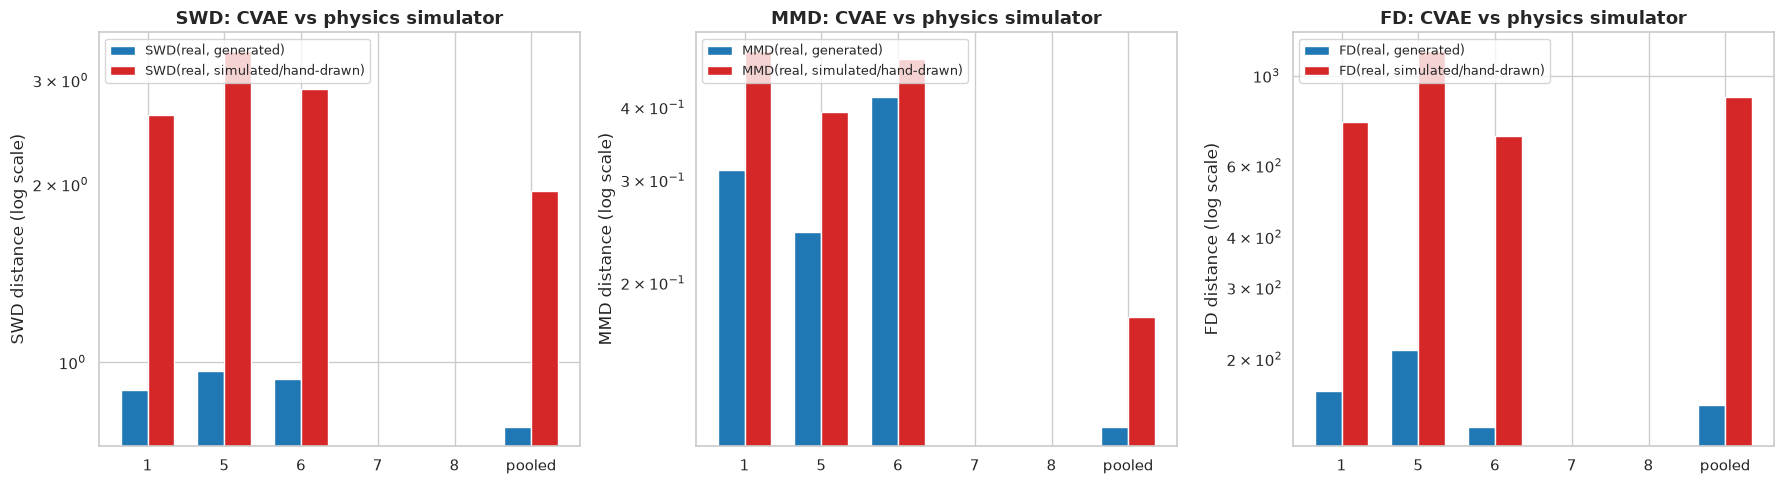

In [15]:
rows = []
rare_blocks = {c: {} for c in RARE_CLASSES}
for c in RARE_CLASSES:
    Xr = extract_features(data, 'real', [c])[0]
    Xg = generate_samples(model, c, 200, feat_mu, feat_sd, seed=42 + c)
    alt_src = 'handdrawn' if c == 7 else 'simulated' # custom choice for class 7 (no simulated data)
    Xa = extract_features(data, alt_src, [c])[0]
    rare_blocks[c] = {'real': Xr, 'gen': Xg, 'alt': Xa, 'alt_src': alt_src}

for c, blk in rare_blocks.items():
    row = {'class': c, 'event': CLASS_NAMES[c][:22],
           'n_real': len(blk['real']), 'n_gen': len(blk['gen']), 
           f"n_{blk['alt_src']}": len(blk['alt'])}
    
    dg = compute_distances(blk['real'], blk['gen'])
    da = compute_distances(blk['real'], blk['alt'])
    for metric in ['SWD', 'MMD', 'FD']:
        row[f'{metric} real<->gen'] = dg[metric] if dg else None
        row[f'{metric} real<->{blk["alt_src"]}'] = da[metric] if da else None
    rows.append(row)

# (class 7 has no simulated data; pooled alt = simulated of classes 1, 5, 6, 8)
Xr_all = np.vstack([rare_blocks[c]['real'] for c in RARE_CLASSES])
Xg_all = np.vstack([rare_blocks[c]['gen'] for c in RARE_CLASSES])
Xa_all = np.vstack([rare_blocks[c]['alt'] for c in [1, 5, 6, 8]])
row = {'class': 'All rare (pooled)', 'event': 'classes 1,5,6,7,8',
       'n_real': len(Xr_all), 'n_gen': len(Xg_all), 'n_simulated': len(Xa_all)}
dg = compute_distances(Xr_all, Xg_all)
da = compute_distances(Xr_all, Xa_all)
for metric in ['SWD', 'MMD', 'FD']:
    row[f'{metric} real<->gen'] = dg[metric]
    row[f'{metric} real<->simulated'] = da[metric]
rows.append(row)

qual_df = pd.DataFrame(rows)
display(qual_df)

# Distance summary to answer if the CVAE data is closer to real than the simulator is
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(qual_df))
width = 0.35
for i, metric in enumerate(['SWD', 'MMD', 'FD']):
    ax = axes[i]
    gen_v = qual_df[f'{metric} real<->gen']
    alt_v = qual_df[f'{metric} real<->simulated'].fillna(qual_df[f'{metric} real<->handdrawn'])
    ax.bar(x - width / 2, gen_v, width, label=f'{metric}(real, generated)', color='#1f77b4')
    ax.bar(x + width / 2, alt_v, width, label=f'{metric}(real, simulated/hand-drawn)', color='#d62728')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{r["class"]}' if isinstance(r["class"], int) else 'pooled' for _, r in qual_df.iterrows()])
    ax.set_ylabel(f'{metric} distance (log scale)')
    ax.set_title(f'{metric}: CVAE vs physics simulator', fontweight='bold', fontsize=13)
    ax.set_yscale('log')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 4. N-sweep to check if generated data bridge the gap

For each augmentation level N we run a single evaluation function that
1. generates N synthetic instances per rare class,
2. augments the real training set,
3. measures the feature-space distance between the augmented rare data and the real rare domain, and
4. trains a Random Forest on the augmented set to measure the rare-aggregate F1 on the untouched test set. 

Distance and downstream performance are therefore measured **together, for every step**. The same protocol is run with simulated (OLGA) instances in place of the CVAE data, so the two generators are compared on identical ground.

**Methods:**
- **Generator**: the CVAE trained once on the training split (Section 2); simulated rows come from the raw OLGA data of classes 1, 5, 6, 8 (class 7 has no simulated   counterpart, class 8 caps at 81 instances).
- **Classifier**: Random Forest (100 trees), 10 seeds (42..51) for variance as in the baseline; only the RF is re-seeded, the generator and the test set are fixed.
- **Configs**: real-only baseline (computed in Section 1); `class_weight='balanced'` (no generation); augmentation with N in {10, 25, 50, 100} generated instances per rare class, for both generators.
- **Evaluation**: always on the untouched real test set (308 instances).
- **Distance**: the SWD/MMD/FD of Section 3 between the augmented rare set and the real rare domain, coupled to the F1 of the same step.
- **Headline metric**: *rare-aggregate F1* = mean over classes {1,5,6,7,8} of the one-vs-rest F1 as already done for the baseline. Test support per rare class is 1-4 instances, so these are 0/1-dominated estimates: the mean over 10 RF seeds and the std are the honest variance.


In [16]:
def evaluate_augmentation(X_gen_by_class: dict, n: int, classes: list) -> dict:
    """
    Per-step evaluation:
    (1) build the augmented training set, (2) measure the feature-space distance
    between the augmented rare data and the real rare domain, (3) evaluate the
    Random Forest on the untouched test set.
    Args:
        X_gen_by_class: dictionary mapping class codes to generated feature matrices
        n: number of generated samples to include per rare class
        classes: list of all class codes for evaluation
    Returns:
        res: dictionary containing evaluation metrics including macro F1, per-class F1, 
        and distance metrics (SWD, MMD, FD) between the augmented rare data and the real rare data
    """
    X_parts, y_parts = [X_train], [y_train]
    gen_parts = []
    for c in RARE_CLASSES:
        if c not in X_gen_by_class:
            continue
        Xg = X_gen_by_class[c][:n]   # might be shorter than n (class 8 simulated has 81 samples)
        X_parts.append(Xg)
        y_parts.append(np.full(len(Xg), c))
        gen_parts.append(Xg)
    X_aug, y_aug = np.vstack(X_parts), np.concatenate(y_parts)
    res = run_rf_evaluation(X_aug, y_aug, X_test, y_test, classes)
    X_aug_rare = np.vstack([X_rare_train] + gen_parts)
    d = compute_distances(X_rare_all, X_aug_rare)
    res['SWD'] = d['SWD']; 
    res['MMD'] = d['MMD']; 
    res['FD'] = d['FD']
    return res

rare_mask = np.isin(y_train, RARE_CLASSES)
X_rare_train = X_train[rare_mask]
X_rare_all = extract_features(data, 'real', RARE_CLASSES)[0]

test_support = {c: int(np.sum(y_test == c)) for c in RARE_CLASSES}
print('Test support (real instances) per rare class:', test_support)


Test support (real instances) per rare class: {1: 1, 5: 4, 6: 2, 7: 1, 8: 1}


In [17]:
AUG_SIZES = [10, 25, 50, 100]

results = {}
results['baseline'] = dict(baseline_results)
d0 = compute_distances(X_rare_all, X_rare_train)
results['baseline']['SWD'] = d0['SWD']; 
results['baseline']['MMD'] = d0['MMD']; 
results['baseline']['FD'] = d0['FD']
results['class_weight=balanced'] = run_rf_evaluation(X_train, y_train, X_test, y_test, all_classes, class_weight='balanced')

# CVAE-generated augmentation (nested draws, fixed per-class seeds)
cva_sets = {c: generate_samples(model, c, max(AUG_SIZES), feat_mu, feat_sd, seed=42 + c)
            for c in RARE_CLASSES}
for n_aug in AUG_SIZES:
    results[f'CVAE +{n_aug}'] = evaluate_augmentation(cva_sets, n_aug, all_classes)

# Identical process with OLGA-simulated instances
# (classes 1, 5, 6, 8; class 7 has no simulated counterpart)
SIM_CLASSES = [c for c in RARE_CLASSES if 'simulated' in data.get(c, {})]
X_sim_by_class = {c: extract_features(data, 'simulated', [c])[0] for c in SIM_CLASSES}
print('Simulated instances available:', {c: len(X_sim_by_class[c]) for c in SIM_CLASSES})

sim_sets = {}
for c in SIM_CLASSES:
    rng = np.random.RandomState(42 + c)
    Xc = X_sim_by_class[c]
    n_use = min(max(AUG_SIZES), len(Xc))
    sim_sets[c] = Xc[rng.choice(len(Xc), n_use, replace=False)]
for n_aug in AUG_SIZES:
    results[f'Sim +{n_aug}'] = evaluate_augmentation(sim_sets, n_aug, all_classes)

rows = []
for name, res in results.items():
    ra_mean, ra_std = rare_agg_per_seed(res)
    row = {'config': name,
           'rare-agg F1': f'{ra_mean:.3f} +/- {ra_std:.3f}',
           'macro-F1': f"{res['macro'].mean():.3f}",
           'SWD': f"{res['SWD']:.3g}" if 'SWD' in res else '-',
           'MMD': f"{res['MMD']:.3f}" if 'MMD' in res else '-',
           'FD': f"{res['FD']:.3g}" if 'FD' in res else '-'}
    for c in RARE_CLASSES:
        row[f'F1 c{c}'] = f"{res['per_class'][c].mean():.2f}"
    rows.append(row)
res_df = pd.DataFrame(rows)
display(res_df)


Simulated instances available: {1: 114, 5: 439, 6: 215, 8: 81}


,config,rare-agg F1,macro-F1,SWD,MMD,FD,F1 c1,F1 c5,F1 c6,F1 c7,F1 c8
0,baseline,0.571 +/- 0.000,0.741,0.115,0.009,6.9,0.00,0.86,1.00,0.00,1.00
1,class_weight=balanced,0.600 +/- 0.000,0.764,-,-,-,0.00,1.00,1.00,0.00,1.00
2,CVAE +10,0.571 +/- 0.000,0.740,0.355,0.054,36.7,0.00,0.86,1.00,0.00,1.00
3,CVAE +25,0.597 +/- 0.009,0.759,0.47,0.079,53.4,0.00,0.99,1.00,0.00,1.00
4,CVAE +50,0.600 +/- 0.000,0.760,0.577,0.094,74.8,0.00,1.00,1.00,0.00,1.00
5,CVAE +100,0.600 +/- 0.000,0.760,0.649,0.102,103,0.00,1.00,1.00,0.00,1.00
6,Sim +10,0.571 +/- 0.000,0.740,0.388,0.065,30.7,0.00,0.86,1.00,0.00,1.00
7,Sim +25,0.571 +/- 0.000,0.740,0.595,0.111,63.5,0.00,0.86,1.00,0.00,1.00
8,Sim +50,0.571 +/- 0.000,0.740,0.808,0.138,117,0.00,0.86,1.00,0.00,1.00
9,Sim +100,0.571 +/- 0.000,0.740,1.06,0.150,215,0.00,0.86,1.00,0.00,1.00


### 4.1 Final comparison: CVAE vs simulated

We plot the rare-aggregate F1 and the SWD distance (the mean-shift metric of the metrics) against the augmentation level N for both generators, with the no-augmentation baseline as a dashed line.


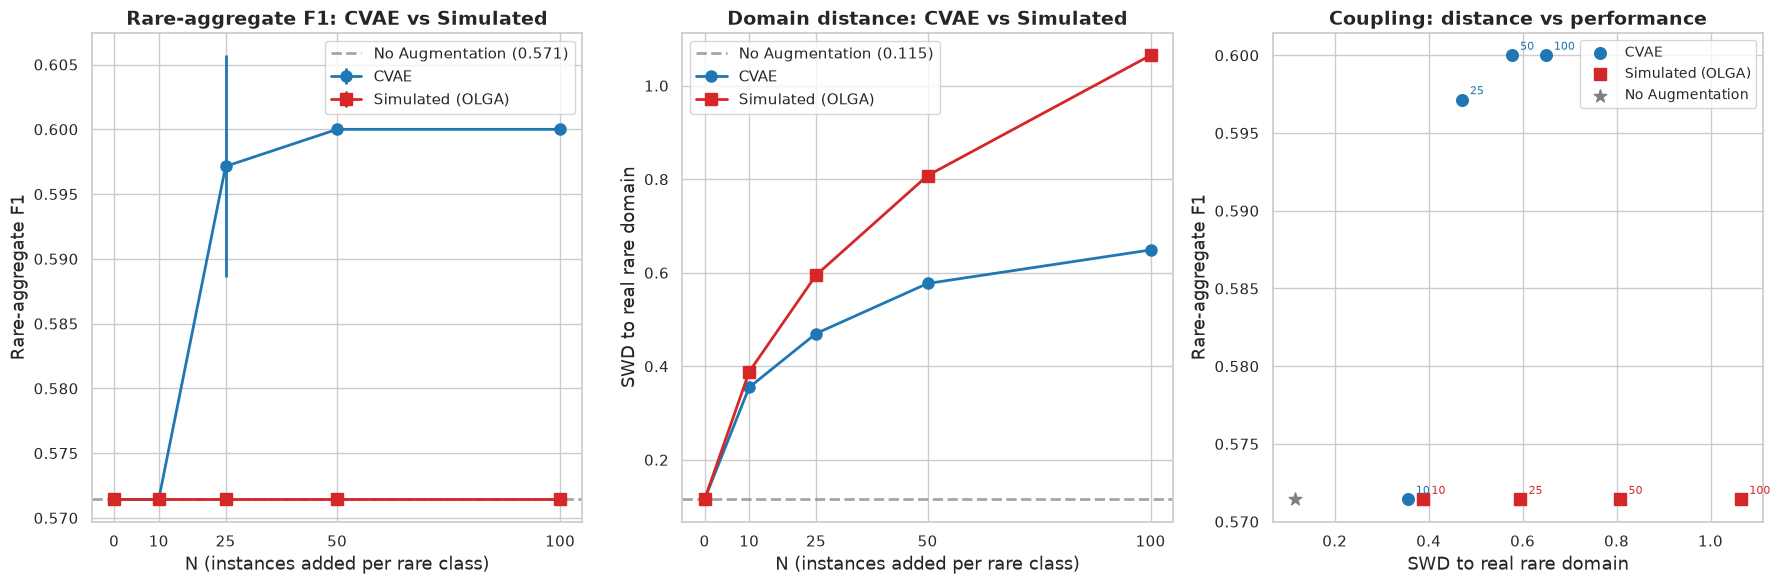

,Method,Best N,Rare-agg F1,SWD,Delta vs baseline
0,No Augmentation,-,0.571,0.115,-
1,class_weight=balanced,-,0.600,-,0.029
2,CVAE (best N),50,0.600,0.577,0.029
3,Simulated (best N),10,0.571,0.388,0.0



Per-class change vs baseline (one-vs-rest F1):

Class 1 (Abrupt Increase of B):


,Method,F1,Delta vs baseline
0,No Augmentation,0.0,-
1,CVAE +50,0.0,0.0
2,Simulated +10,0.0,0.0



Class 5 (Rapid Productivity L):


,Method,F1,Delta vs baseline
0,No Augmentation,0.857,-
1,CVAE +50,1.000,0.143
2,Simulated +10,0.857,0.0


...

,Method,F1,Delta vs baseline
0,No Augmentation,1.0,-
1,CVAE +50,1.0,0.0
2,Simulated +10,1.0,0.0



Class 7 (Scaling in PCK):


,Method,F1,Delta vs baseline
0,No Augmentation,0.0,-
1,CVAE +50,0.0,0.0
2,Simulated +10,0.0,0.0



Class 8 (Hydrate in Productio):


,Method,F1,Delta vs baseline
0,No Augmentation,1.0,-
1,CVAE +50,1.0,0.0
2,Simulated +10,1.0,0.0


In [18]:
xs = [0] + AUG_SIZES
baseline_ra, baseline_rs = rare_agg_per_seed(results['baseline'])
baseline_swd = results['baseline']['SWD']

def series(prefix, key, xs):
    vals = []
    for x in xs:
        name = f'{prefix} +{x}' if x > 0 else 'baseline'
        res = results[name]
        if key == 'rare':
            vals.append(rare_agg_per_seed(res)[0])
        elif key == 'macro':
            vals.append(res['macro'].mean())
        else:
            vals.append(res[key])
    return np.array(vals)

cva_ra = series('CVAE', 'rare', xs)
sim_ra = series('Sim', 'rare', xs)
cva_swd = series('CVAE', 'SWD', xs)
sim_swd = series('Sim', 'SWD', xs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rare-aggregate F1 vs N
ax = axes[0]
ax.axhline(y=baseline_ra, color='gray', linestyle='--', linewidth=2, alpha=0.7,
           label=f'No Augmentation ({baseline_ra:.3f})')
ax.errorbar(xs, cva_ra, fmt='o-', yerr=[baseline_rs] + [rare_agg_per_seed(results[f"CVAE +{x}"])[1] for x in xs[1:]],
            color='#1f77b4', linewidth=2, markersize=8, label='CVAE')
ax.errorbar(xs, sim_ra, fmt='s-', yerr=[baseline_rs] + [rare_agg_per_seed(results[f"Sim +{x}"])[1] for x in xs[1:]],
            color='#d62728', linewidth=2, markersize=8, label='Simulated (OLGA)')
ax.set_xlabel('N (instances added per rare class)', fontsize=13)
ax.set_ylabel('Rare-aggregate F1', fontsize=13)
ax.set_xticks(xs)
ax.set_title('Rare-aggregate F1: CVAE vs Simulated', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)

# Distance to the real domain vs N
ax = axes[1]
ax.axhline(y=baseline_swd, color='gray', linestyle='--', linewidth=2, alpha=0.7,
           label=f'No Augmentation ({baseline_swd:.3g})')
ax.plot(xs, cva_swd, 'o-', color='#1f77b4', linewidth=2, markersize=8, label='CVAE')
ax.plot(xs, sim_swd, 's-', color='#d62728', linewidth=2, markersize=8, label='Simulated (OLGA)')
ax.set_xlabel('N (instances added per rare class)', fontsize=13)
ax.set_ylabel('SWD to real rare domain', fontsize=13)
ax.set_xticks(xs)
ax.set_title('Domain distance: CVAE vs Simulated', fontweight='bold', fontsize=14)
ax.legend(fontsize=11)

# Distance vs F1 coupling
ax = axes[2]
ax.scatter(cva_swd[1:], cva_ra[1:], color='#1f77b4', s=70, marker='o', label='CVAE')
ax.scatter(sim_swd[1:], sim_ra[1:], color='#d62728', s=70, marker='s', label='Simulated (OLGA)')
ax.scatter([baseline_swd], [baseline_ra], color='gray', s=90, marker='*', zorder=5,
           label='No Augmentation')
for x, d, f in zip(xs[1:], cva_swd[1:], cva_ra[1:]):
    ax.annotate(str(x), (d, f), textcoords='offset points', xytext=(6, 4), fontsize=8, color='#1f77b4')
for x, d, f in zip(xs[1:], sim_swd[1:], sim_ra[1:]):
    ax.annotate(str(x), (d, f), textcoords='offset points', xytext=(6, 4), fontsize=8, color='#d62728')
ax.set_xlabel('SWD to real rare domain', fontsize=13)
ax.set_ylabel('Rare-aggregate F1', fontsize=13)
ax.set_title('Coupling: distance vs performance', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

def best_config(prefix: str) -> tuple:
    """
    Find the best configuration (highest rare-aggregate F1) for a given prefix in the results.
    Args:
        prefix: string prefix to filter the results (e.g., 'CVAE' or 'Sim')
    Returns:
        tuple containing:
            - best configuration name (str)
            - number of instances added per rare class (int)
            - mean rare-aggregate F1 (float)
            - standard deviation of rare-aggregate F1 (float)
            - SWD to real rare domain (float)
    """
    names = [k for k in results if k.startswith(prefix)]
    best = max(names, key=lambda k: rare_agg_per_seed(results[k])[0])
    ra, rs = rare_agg_per_seed(results[best])
    return best, int(best.split('+')[1]), ra, rs, results[best]['SWD']

best_cva, n_cva, ra_cva, rs_cva, swd_cva = best_config('CVAE')
best_sim, n_sim, ra_sim, rs_sim, swd_sim = best_config('Sim')
bal_ra, bal_rs = rare_agg_per_seed(results['class_weight=balanced'])

summary = pd.DataFrame({
    'Method': ['No Augmentation', 'class_weight=balanced', f'CVAE (best N)', f'Simulated (best N)'],
    'Best N': ['-', '-', n_cva, n_sim],
    'Rare-agg F1': [round(baseline_ra, 3), round(bal_ra, 3), round(ra_cva, 3), round(ra_sim, 3)],
    'SWD': [round(baseline_swd, 3), '-', round(swd_cva, 3), round(swd_sim, 3)],
    'Delta vs baseline': ['-', round(bal_ra - baseline_ra, 3),
                          round(ra_cva - baseline_ra, 3), round(ra_sim - baseline_ra, 3)],
})

display(summary)

print('\nPer-class change vs baseline (one-vs-rest F1):')
for c in RARE_CLASSES:
    b = results['baseline']['per_class'][c].mean()
    v = results[best_cva]['per_class'][c].mean()
    s = results[best_sim]['per_class'][c].mean()
    df_res = pd.DataFrame({
        'Method': ['No Augmentation', f'CVAE +{n_cva}', f'Simulated +{n_sim}'],
        'F1': [round(b, 3), round(v, 3), round(s, 3)],
        'Delta vs baseline': ['-', round(v - b, 3), round(s - b, 3)],
    })
    print(f'\nClass {c} ({CLASS_NAMES[c][:20]}):')
    display(df_res)

## 5. VAE Anomaly Detection

Alternative use of the same generative process: a VAE trained **only on Normal instances** (class 0, 418 of the Section-1 training instances) learns the normal operating envelope. Any instance whose reconstruction error is far from the training distribution is an anomaly, that is, one of the 8 undesirable events. The VAE is scored against three classical detectors (Mahalanobis, kNN, Isolation Forest) with ROC-AUC and F1 at a fixed threshold.

Same encoder/decoder architecture as the CVAE, minus the class condition. Standardization is fit on class-0 training instances only; every test instance (including faulty ones) is transformed with the same statistics.

**Architecture:** (same as CVAE, minus the class condition)
- **Encoder**: Input (56 features) → 64 → 64 → μ, σ (latent dim = 8)
- **Decoder**: Latent (8) → 64 → 64 → 56 reconstructed features
- **Loss**: Reconstruction (MSE) + KL Divergence


In [19]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, latent_dim: int = 8, hidden: int = 64):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def forward(self, x: torch.Tensor) -> tuple:
        h = self.encoder(x)
        mu, logvar = self.mu_head(h), self.logvar_head(h)
        z = self.reparameterize(mu, logvar)
        return self.decoder(z), mu, logvar


In [20]:
X0 = X_train[y_train == 0]
mu0 = np.mean(X0, axis=0)
sd0 = np.std(X0, axis=0)
degenerate0 = sd0 < 1e-12
sd0[degenerate0] = 1.0

def zscore(X: np.ndarray) -> np.ndarray:
    return ((X - mu0) / sd0).astype(np.float32)

X0_std = zscore(X0)
print(f'Class 0 train instances: {len(X0)}')
print(f'Class 0 test instances: {int(np.sum(y_test == 0))} (negatives)')
print(f'Faulty test instances: {int(np.sum(y_test != 0))} across 8 event classes')


Class 0 train instances: 418
Class 0 test instances: 179 (negatives)
Faulty test instances: 129 across 8 event classes


epoch  25 | ELBO 0.7299 | recon 0.6394 | KL 0.0905
epoch  50 | ELBO 0.5993 | recon 0.4786 | KL 0.1207
epoch  75 | ELBO 0.5440 | recon 0.3961 | KL 0.1479
epoch 100 | ELBO 0.5197 | recon 0.3641 | KL 0.1556
epoch 125 | ELBO 0.4598 | recon 0.2872 | KL 0.1726
epoch 150 | ELBO 0.4640 | recon 0.2704 | KL 0.1936
epoch 175 | ELBO 0.4370 | recon 0.2388 | KL 0.1982
epoch 200 | ELBO 0.4220 | recon 0.2156 | KL 0.2065

Final mean KL: 0.2065 nats/sample


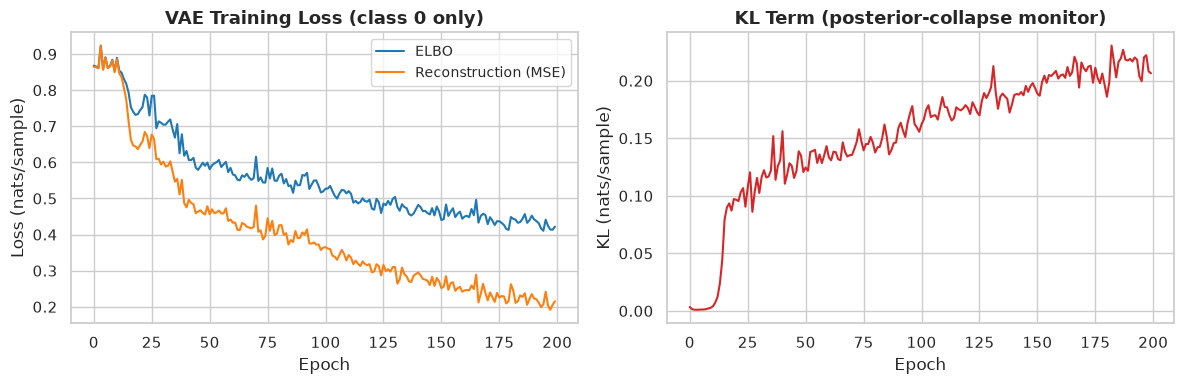

In [21]:
set_seed(42)
model = VAE(input_dim=X_train.shape[1], latent_dim=8, hidden=64)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loader = DataLoader(TensorDataset(torch.tensor(X0_std)), batch_size=64, shuffle=True)

history = {'elbo': [], 'recon': [], 'kl': []}
for epoch in range(1, 201):
    model.train()
    e_elbo = e_recon = e_kl = 0.0
    n_batches = 0
    for (xb,) in loader:
        optimizer.zero_grad()
        x_rec, mu, logvar = model(xb)
        loss, recon, kl = elbo_loss(xb, x_rec, mu, logvar)
        loss.backward()
        optimizer.step()
        e_elbo += loss.item(); e_recon += recon.item(); e_kl += kl.item()
        n_batches += 1
    history['elbo'].append(e_elbo / n_batches)
    history['recon'].append(e_recon / n_batches)
    history['kl'].append(e_kl / n_batches)
    if epoch % 25 == 0:
        print(f'epoch {epoch:3d} | ELBO {history["elbo"][-1]:.4f} | recon {history["recon"][-1]:.4f} | KL {history["kl"][-1]:.4f}')

print(f'\nFinal mean KL: {history["kl"][-1]:.4f} nats/sample')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['elbo'], label='ELBO', color='#1f77b4', linewidth=1.5)
axes[0].plot(history['recon'], label='Reconstruction (MSE)', color='#ff7f0e', linewidth=1.5)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (nats/sample)')
axes[0].set_title('VAE Training Loss (class 0 only)', fontweight='bold', fontsize=13)
axes[0].legend(fontsize=10)
axes[1].plot(history['kl'], color='#d62728', linewidth=1.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('KL (nats/sample)')
axes[1].set_title('KL Term (posterior-collapse monitor)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


### 5.1 Anomaly scoring

Anomaly score = per-sample mean squared reconstruction error on the
standardized features. The threshold is fixed at the 95th percentile of the
**training** normal scores; no test data is used to set it.


In [22]:
@torch.no_grad()
def anomaly_scores(model: nn.Module, X_std: np.ndarray, batch: int = 256) -> np.ndarray:
    model.eval()
    scores = []
    for i in range(0, len(X_std), batch):
        x = torch.tensor(X_std[i:i + batch])
        x_rec, _, _ = model(x)
        scores.append(((x - x_rec) ** 2).mean(dim=1).numpy())
    return np.concatenate(scores)

scores_train_norm = anomaly_scores(model, X0_std)
thr = np.percentile(scores_train_norm, 95)
scores_test = anomaly_scores(model, zscore(X_test))
print(f'Anomaly threshold (p95 of train-normal scores): {thr:.4f}')
print(f'Train-normal score range: [{scores_train_norm.min():.4f}, {scores_train_norm.max():.4f}]')

Anomaly threshold (p95 of train-normal scores): 0.5885
Train-normal score range: [0.0024, 4.4233]


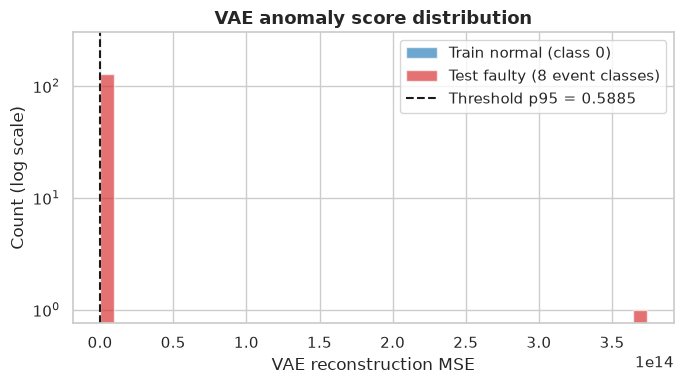

,class,event,n,mean score,mean / normal p95
0,1,Abrupt Increase of BSW,1,1.363467e+00,2.316671e+00
1,2,Spurious Closure of DHSV,7,9.493949e+02,1.613120e+03
2,3,Severe Slugging,10,1.321273e+03,2.244979e+03
3,4,Flow Instability,103,1.654105e+01,2.810496e+01
4,5,Rapid Productivity Loss,4,1.138595e+04,1.934591e+04
5,6,Quick Restriction in PCK,2,5.683562e-01,9.656960e-01
6,7,Scaling in PCK,1,3.736577e+14,6.348830e+14
7,8,Hydrate in Production Line,1,8.512333e+05,1.446334e+06


In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(scores_train_norm, bins=30, alpha=0.65, label='Train normal (class 0)', color='#1f77b4')
fault_scores = scores_test[y_test != 0]
ax.hist(fault_scores, bins=40, alpha=0.65, label='Test faulty (8 event classes)', color='#d62728')
ax.axvline(thr, color='k', ls='--', label=f'Threshold p95 = {thr:.4f}')
ax.set_yscale('log')
ax.set_xlabel('VAE reconstruction MSE'); ax.set_ylabel('Count (log scale)')
ax.set_title('VAE anomaly score distribution', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

score_rows = []
for c in sorted(CLASS_NAMES):
    if c == 0:
        continue
    mask = y_test == c
    if mask.sum() == 0:
        continue
    score_rows.append({'class': c, 'event': CLASS_NAMES[c][:26], 'n': int(mask.sum()),
                       'mean score': scores_test[mask].mean(),
                       'mean / normal p95': scores_test[mask].mean() / thr})
score_df = pd.DataFrame(score_rows)
display(score_df)


### 5.2 Baselines

Three classical detectors on the same standardized feature space, scored with
the same protocol (threshold = p95 of their own training-normal scores):
Mahalanobis distance, kNN (k=5) mean neighbor distance, Isolation Forest
(negative decision function).


In [24]:
# Mahalanobis distance
mu_m = np.mean(X0_std, axis=0)
cov_m = np.cov(X0_std, rowvar=False) + 1e-6 * np.eye(X0_std.shape[1])
cov_inv = np.linalg.pinv(cov_m)
def mahalanobis_scores(X):
    dx = X - mu_m
    return np.einsum('ij,jk,ik->i', dx, cov_inv, dx)

# kNN (k=5) mean neighbor distance
knn = NearestNeighbors(n_neighbors=5).fit(X0_std)
def knn_scores(X):
    dists, _ = knn.kneighbors(X)
    return dists.mean(axis=1)

# Isolation Forest (negative decision function so that higher = more anomalous)
iso = IsolationForest(contamination='auto', random_state=42).fit(X0_std)
def iso_scores(X):
    return -iso.decision_function(X)

train_scores = {'VAE (recon MSE)': scores_train_norm,
                'Mahalanobis': mahalanobis_scores(X0_std),
                'kNN (k=5)': knn_scores(X0_std),
                'IsolationForest': iso_scores(X0_std)}
test_scores = {'VAE (recon MSE)': scores_test,
               'Mahalanobis': mahalanobis_scores(zscore(X_test)),
               'kNN (k=5)': knn_scores(zscore(X_test)),
               'IsolationForest': iso_scores(zscore(X_test))}

### 5.3 Evaluation: ROC-AUC and F1@p95

Per-class ROC-AUC (positives = test instances of class c, negatives = the 179 class-0 test instances). Classes with n_test < 3 are considered as unreliable; their AUC is a 1-4 sample estimate. Macro-AUC is computed over the reliable classes only. F1@p95 is measured at the fixed threshold on the full test set (faulty vs normal), plus per-class recall at that threshold.


In [25]:
auc_rows = []
for c in sorted(CLASS_NAMES):
    if c == 0:
        continue
    n_pos = int(np.sum(y_test == c))
    if n_pos == 0:
        continue
    y_true = (y_test == c)
    for mname, scores in test_scores.items():
        auc_rows.append({'class': c, 'event': CLASS_NAMES[c][:24], 'n_test': n_pos,
                         'method': mname, 'AUC': roc_auc_score(y_true, scores)})

auc_df = pd.DataFrame(auc_rows)
auc_pivot = auc_df.pivot(index='class', columns='method', values='AUC')
auc_pivot['n_test'] = auc_df.groupby('class')['n_test'].first()
display(auc_pivot)

macro_auc = auc_df[auc_df['n_test'] >= 3].groupby('method')['AUC'].mean().round(3)
print('Macro-AUC over classes with n_test >= 3 (classes 2, 3, 4, 5):')
display(macro_auc)


method,IsolationForest,Mahalanobis,VAE (recon MSE),kNN (k=5),n_test
class,,,,,
1,0.671010,0.827362,0.846906,0.833876,1
2,0.741813,0.938301,0.965828,0.966303,7
3,1.000000,0.984564,0.979195,0.978859,10
4,0.846223,0.843618,0.730239,0.861189,103
5,0.921875,0.888980,0.947368,0.922697,4
6,0.575163,0.839869,0.704248,0.710784,2
7,0.677524,1.000000,1.000000,1.000000,1
8,0.944625,0.996743,0.996743,0.996743,1


Macro-AUC over classes with n_test >= 3 (classes 2, 3, 4, 5):


method
IsolationForest    0.877
Mahalanobis        0.914
VAE (recon MSE)    0.906
kNN (k=5)          0.932
Name: AUC, dtype: float64

In [26]:
f1_rows = []
recall_rows = []
for mname in test_scores:
    thr_m = np.percentile(train_scores[mname], 95)
    y_true_f = (y_test != 0)
    y_pred_f = test_scores[mname] > thr_m
    f1_rows.append({
        'method': mname,
        'F1@p95': f1_score(y_true_f, y_pred_f),
        'precision': precision_score(y_true_f, y_pred_f),
        'recall': recall_score(y_true_f, y_pred_f),
    })
    for c in sorted(CLASS_NAMES):
        if c == 0:
            continue
        mask = y_test == c
        if mask.sum() == 0:
            continue
        recall_rows.append({'method': mname, 'class': c, 'n_test': int(mask.sum()),
                            'recall@p95': np.mean(test_scores[mname][mask] > thr_m)})

print('F1, precision, recall at the fixed p95 threshold (faulty vs normal):')
f1_df = pd.DataFrame(f1_rows)
display(f1_df)

print('Per-class recall at the fixed p95 threshold:')
recall_pivot = pd.DataFrame(recall_rows).pivot(index='class', columns='method', values='recall@p95')
recall_pivot['n_test'] = pd.DataFrame(recall_rows).groupby('class')['n_test'].first()
display(recall_pivot)

F1, precision, recall at the fixed p95 threshold (faulty vs normal):


,method,F1@p95,precision,recall
0,VAE (recon MSE),0.666667,0.845238,0.550388
1,Mahalanobis,0.857143,0.812500,0.906977
2,kNN (k=5),0.805031,0.677249,0.992248
3,IsolationForest,0.767241,0.864078,0.689922


Per-class recall at the fixed p95 threshold:


method,IsolationForest,Mahalanobis,VAE (recon MSE),kNN (k=5),n_test
class,,,,,
1,1.000000,1.000000,1.000000,1.000000,1
2,1.000000,1.000000,1.000000,1.000000,7
3,1.000000,1.000000,1.000000,1.000000,10
4,0.621359,0.883495,0.446602,0.990291,103
5,1.000000,1.000000,1.000000,1.000000,4
6,0.500000,1.000000,0.500000,1.000000,2
7,1.000000,1.000000,1.000000,1.000000,1
8,1.000000,1.000000,1.000000,1.000000,1


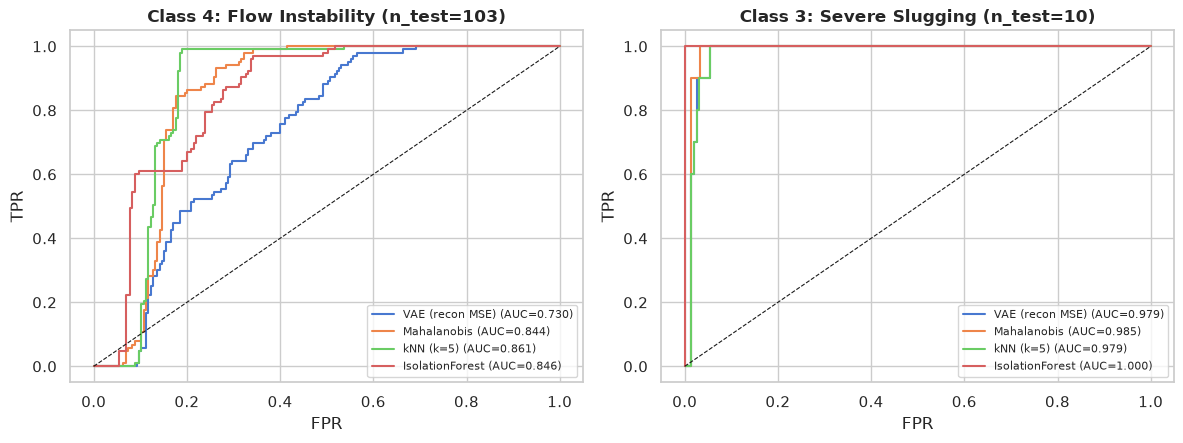

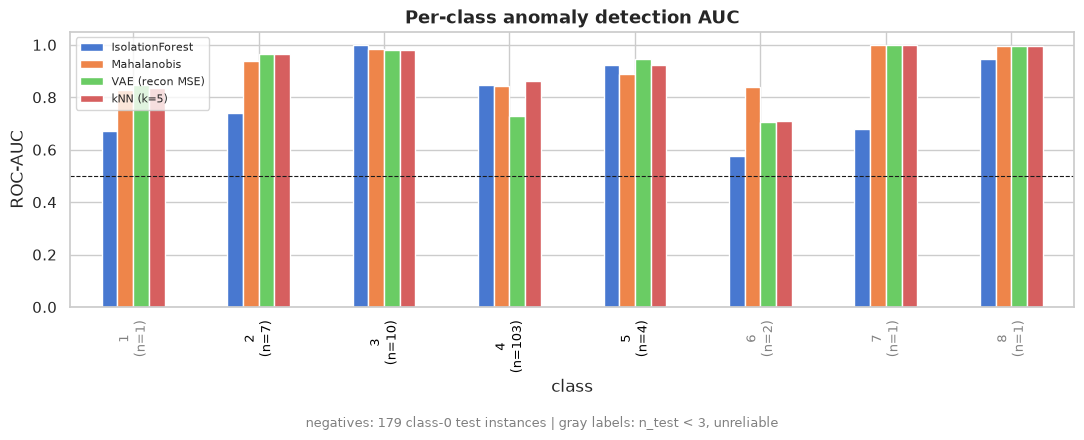

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, c in zip(axes, [4, 3]): # class 4 (n=103) and class 3 (n=10), the most reliable classes
    y_true = (y_test == c)
    for mname, scores in test_scores.items():
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(fpr, tpr, label=f'{mname} (AUC={roc_auc_score(y_true, scores):.3f})')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(f'Class {c}: {CLASS_NAMES[c][:30]} (n_test={int(np.sum(y_test == c))})', fontweight='bold', fontsize=12)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

N_NEG = int(np.sum(y_test == 0)) # class-0 test instances used as negatives for every class
MIN_N = 3 # test support below which a per-class AUC is unreliable

fig, ax = plt.subplots(figsize=(11, 4.4))
plot_df = auc_pivot.drop(columns=['n_test'])
plot_df.plot(kind='bar', ax=ax)
ax.set_ylabel('ROC-AUC')
ax.set_xticklabels([f'{int(c)}\n(n={int(n)})' for c, n in zip(plot_df.index, auc_pivot['n_test'])], fontsize=9)
ax.axhline(0.5, color='k', ls='--', lw=0.8)
ax.set_title('Per-class anomaly detection AUC', fontweight='bold', fontsize=13)
fig.text(0.5, 0.01,f'negatives: {N_NEG} class-0 test instances | gray labels: n_test < {MIN_N}, unreliable', ha='center', fontsize=9, color='gray')

auc_pivot['reliable'] = auc_pivot['n_test'] >= MIN_N

for i, c in enumerate(plot_df.index):
    if auc_pivot.loc[c, 'reliable']:
        ax.get_xticklabels()[i].set_color('black')
    else:
        ax.get_xticklabels()[i].set_color('gray')
ax.legend(fontsize=8)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 6. Conclusion

**Experiment A (CVAE rare-event augmentation)**
1. **The conditioning works.** The class label collapses the class separability in the latent space: the mean pairwise class-centroid distance drops from 22.44 in feature space to 0.88 in the latent space (96.1% collapse), confirming that the CVAE stores the class identity in the condition, not in the latent code.

2. **The generated data is closer to the real domain than the physics simulator.** On the SWD/MMD/FD metrics, pooled over the rare classes: SWD 0.778 vs 1.951, MMD 0.113 vs 0.175, FD 154 vs 885. The per-class comparison agrees for every computable class (1, 5, 6, with at least 5 real instances each); classes 7 and 8 stay n/a below 5 samples per side, where generation fidelity degrades the most.

3. **CVAE augmentation improves the rare events; the simulator does not.** The rare-aggregate F1 rises from 0.571 (no augmentation) to 0.600 at N = 50 and above (delta +0.029, matching the `class_weight='balanced'` reference), while the simulated data is flat at 0.571 for every N. The entire CVAE gain comes from class 5 (0.86 to 1.00); classes 1 and 7 stay at 0.00 with a single test instance each.

4. **Distance and performance move together.** The augmented-set distance to the real domain grows with N for both generators, but more slowly for the CVAE (SWD 0.649 vs 1.06 at N = 100; MMD lower at every step, FD from N = 25 on); for the same distance budget, the CVAE's F1 rises while the simulator's stays flat. Quantity does not compensate for quality.

**Experiment B (VAE anomaly detection)**

5. **Most fault classes separate cleanly from the normal envelope.** Classes 2, 3, 5, 7, 8 reach AUC >= 0.94 with the best method (mean VAE scores from 1.6e3x to 6e14x the normal p95 threshold); class 3 is the only one detected at AUC >= 0.97 by every method. Classes 1 and 6 are single/two-sample estimates (n_test 1 and 2) where the methods disagree.

6. Class 4 (Flow Instability, n=103) is the hard case: recall@p95 kNN 0.990 > Mahalanobis 0.883 > IsolationForest 0.621 > VAE 0.447. The VAE reconstructs the most normal-like fault too well.

7. Macro-AUC (on reliable classes 2, 3, 4, 5): kNN 0.932 > Mahalanobis 0.914 > VAE 0.906 > IsolationForest 0.877. F1@p95 (fixed threshold): Mahalanobis 0.857 > kNN 0.805 > IsolationForest 0.767 > VAE 0.667. The VAE has the best precision (0.845) but the worst recall (0.550), again due to class 4.

8. Reconstruction-based detection fails precisely where a fault is most similar to normal (Flow Instability, the most common real fault), distance-based methods (kNN, Mahalanobis) are more robust there. The class-4 blind spot is shared with IsolationForest, not with distance methods.

**Limitations**

9. Per-class test supports of 1 to 4 instances make per-class F1 0/1-dominated, and the classes with 2 to 4 training instances dominate the generation error (mean deviation up to 13.5 std units for class 8).
